stroke: 0.11


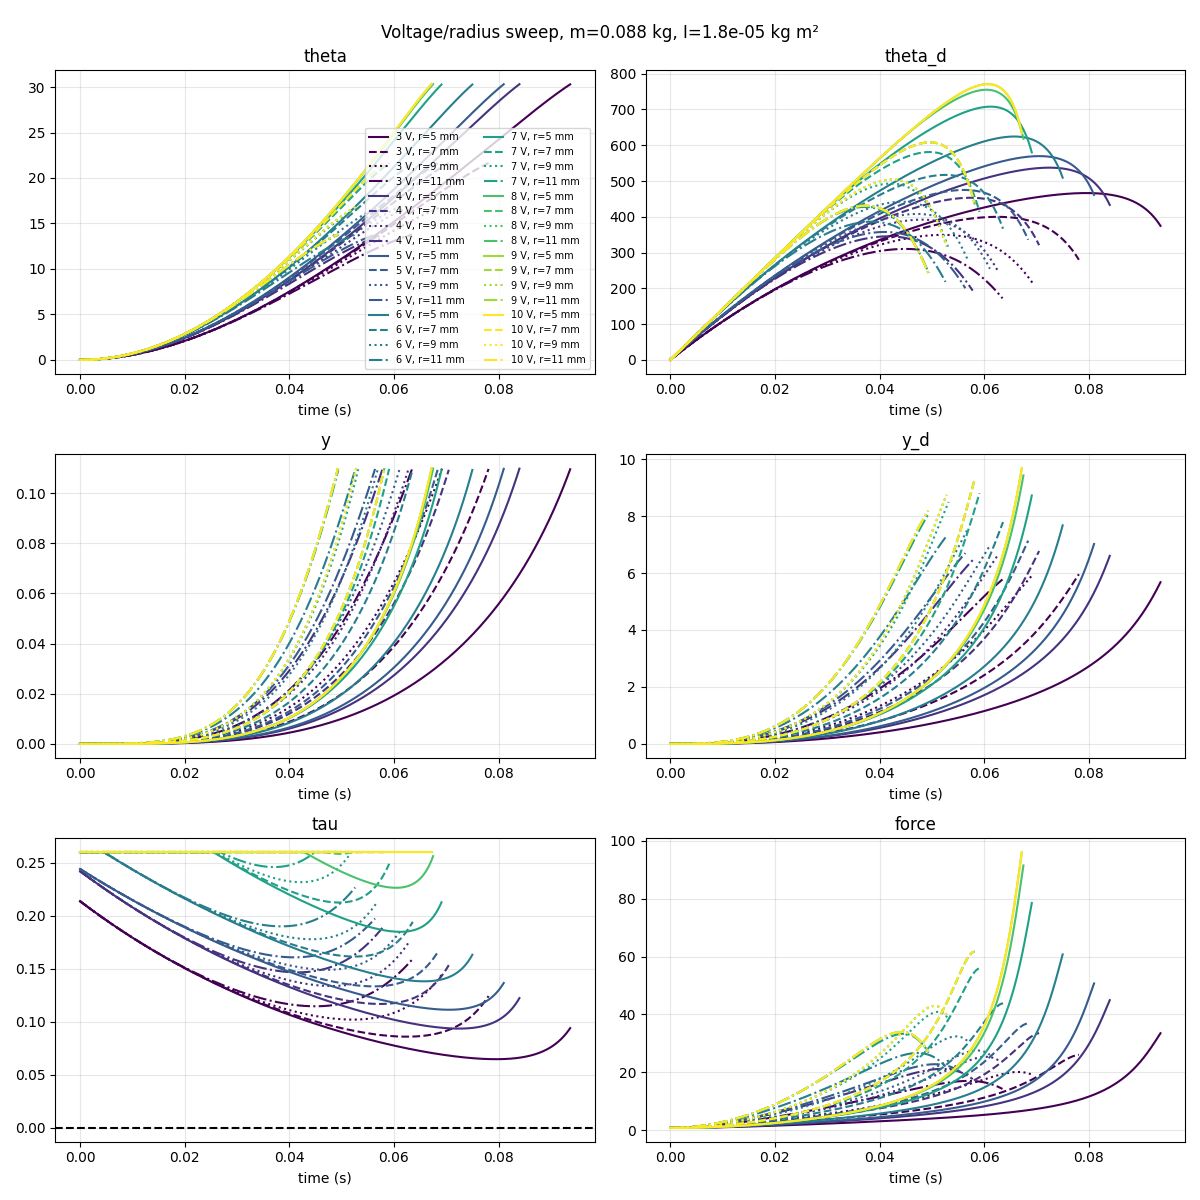

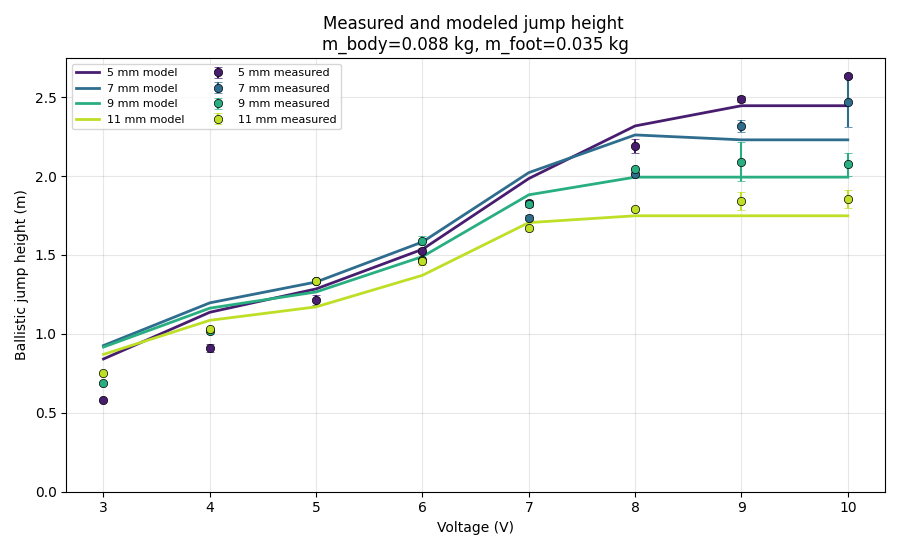

In [25]:
import numpy as np
from scipy.integrate import solve_ivp
from scipy.optimize import least_squares
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib widget
plt.close('all')

L = 0.1595 # 35*0.0045 #32 spacers, 4.5mm spacing
# r = 0.005
stroke = L - 0.0495
mass = 0.088 # just the body
mass_total = 0.123
mass_foot = mass_total - mass
# mass = 0.040
I_BASELINE = 4e-6
I = 1.82396e-5  # fitted after correcting measured heights by the 2.5 in origin offset
print(f"stroke: {stroke}")

params = {
    'm': mass,
    'I': I,
    'stroke': stroke,
    'g': 9.81,
    'voltage': 7.0,
}

def get_y_tsa(theta):
    val = L**2 - (r*theta)**2
    if val < 1e-12:
        val = 1e-12
    y = L - np.sqrt(val)
    dy_dtheta = (r**2 * theta) / np.sqrt(val)
    d2y_dtheta2 = (r**2 * L**2) / (val)**(3/2)
    return y, dy_dtheta, d2y_dtheta2

VOLTAGE_POINTS = np.arange(1.0, 11.0)
FREE_SPEED_RPM = np.array([
    2049.7002, 4224.7279, 6390.3895, 8368.1081, 10005.7876,
    12022.9659, 14866.4361, 17137.8066, 19872.9528, 21643.4236,
])
SLOPE_0 = -4.70391607e-5  # Nm/RPM
SLOPE_RATE = 4.52823176e-6  # Nm/RPM/V
SLOPE_KNEE_V = 5.352084
TORQUE_CAP_BASELINE_NM = 0.207999  # previous 90 A model
TORQUE_CAP_NM = 0.260  # measured plateau with the ESC fixed at 120 A

def get_tau(voltage, rpm):
    if not 1.0 <= voltage <= 10.0:
        raise ValueError('voltage must be within the fitted 1-10 V range')
    free_speed_rpm = np.interp(voltage, VOLTAGE_POINTS, FREE_SPEED_RPM)
    slope = SLOPE_0 + SLOPE_RATE * min(voltage, SLOPE_KNEE_V)
    uncapped_tau = slope * (rpm - free_speed_rpm)
    return min(uncapped_tau, TORQUE_CAP_NM)

def integrate_theta(get_y, get_tau, params, theta0=0, theta_dot0=0, fric=0):
    m = params['m']
    I = params['I']
    stroke = params['stroke']
    g = params['g']
   
    def dynamics(t, state):
        theta, theta_dot = state
        y, dy_dtheta, d2y_dtheta2 = get_y(theta)
        rpm = theta_dot * 60 / (2 * np.pi)
        tau = get_tau(params['voltage'], rpm)
        theta_ddot = (-theta_dot**2 * m * dy_dtheta * d2y_dtheta2 - m*g*dy_dtheta - fric*dy_dtheta + tau) / (I + m * (dy_dtheta)**2)
        return [theta_dot, theta_ddot]
    
    def y_target_event(t, state):
        theta, theta_dot = state
        y, _, _ = get_y(theta)
        return y - stroke
    
    y_target_event.terminal = True
    y_target_event.direction = 0

    t_max = 2.0
    t_eval = np.arange(0, t_max, 0.0001)
    
    sol = solve_ivp(
        dynamics,
        t_span=(0, t_max),
        y0=[theta0, theta_dot0],
        method='BDF',
        t_eval=t_eval,
        events=y_target_event,
        dense_output=True,
        rtol=1e-6,
        atol=1e-9,
    )
    
    t = sol.t
    theta = sol.y[0]
    theta_d = sol.y[1]
    theta_dd = np.zeros_like(theta)
    
    y = np.zeros_like(theta)
    y_d = np.zeros_like(theta)
    y_dd = np.zeros_like(theta)
    tau = np.zeros_like(theta)
    force = np.zeros_like(theta)
    for i, (th, th_d) in enumerate(zip(theta, theta_d)):
        y_val, dy_dtheta, d2y_dtheta2 = get_y(th)
        _,th_dd = dynamics(t[i], [th, th_d])
        theta_dd[i] = th_dd
        y[i] = y_val
        y_d[i] = dy_dtheta * th_d
        y_dd[i] = dy_dtheta * th_dd + d2y_dtheta2 * th_d**2
        rpm = th_d * 60 / (2 * np.pi)
        tau[i] = get_tau(params['voltage'], rpm)
        force[i] = mass * (g + y_dd[i])

    
    return pd.DataFrame({
        't': t,
        'theta': theta,
        'theta_d': theta_d,
        'theta_dd': theta_dd,
        'y': y,
        'y_d': y_d,
        'y_dd': y_dd,
        'tau': tau,
        'force': force,
    })



fig, axs = plt.subplots(3, 2, figsize=(12, 12))
voltage_tests = np.arange(3.0, 11.0, 1.0)
radius_tests = [0.005, 0.007, 0.009, 0.011]
colors = plt.cm.viridis(np.linspace(0, 1, len(voltage_tests)))
line_styles = ['-', '--', ':', '-.']
jump_rows = []

for voltage_test, color in zip(voltage_tests, colors):
    for r_test, line_style in zip(radius_tests, line_styles):
        params['voltage'] = voltage_test
        r = r_test
        res = integrate_theta(get_y_tsa, get_tau, params, theta0=0, theta_dot0=0)
        label = f'{voltage_test:.0f} V, r={1000*r_test:.0f} mm'
        final_y_d = res['y_d'].iloc[-1]
        v_takeoff = final_y_d * mass / (mass + mass_foot)
        jump_height = v_takeoff**2 / (2 * params['g'])
        jump_rows.append({
            'voltage_v': voltage_test,
            'radius_m': r_test,
            'final_y_d_m_s': final_y_d,
            'v_takeoff_m_s': v_takeoff,
            'jump_height_m': jump_height,
        })

        axs[0,0].plot(res['t'], res['theta'], color=color, linestyle=line_style, label=label)
        axs[0,1].plot(res['t'], res['theta_d'], color=color, linestyle=line_style)
        axs[1,0].plot(res['t'], res['y'], color=color, linestyle=line_style)
        axs[1,1].plot(res['t'], res['y_d'], color=color, linestyle=line_style)
        axs[2,0].plot(res['t'], res['tau'], color=color, linestyle=line_style)
        axs[2,1].plot(res['t'], res['force'], color=color, linestyle=line_style)

axs[0,0].set_title('theta')
axs[0,0].legend(fontsize=7, ncol=2)
axs[0,1].set_title('theta_d')
axs[1,0].set_title('y')
axs[1,1].set_title('y_d')
axs[2,0].axhline(0, color='k', linestyle='--')
axs[2,0].set_title('tau')
axs[2,1].set_title('force')
for ax in axs.flat:
    ax.grid(alpha=0.3)
    ax.set_xlabel('time (s)')
fig.suptitle(f'Voltage/radius sweep, m={params["m"]} kg, I={params["I"]:.1e} kg m²')
fig.tight_layout()

jump_results = pd.DataFrame(jump_rows)
trial_path = 'consolidated_data/DNA jumper test - trials august.csv'
trial_data = pd.read_csv(trial_path)
HEIGHT_ORIGIN_OFFSET_IN = 2.5
HEIGHT_ORIGIN_OFFSET_M = HEIGHT_ORIGIN_OFFSET_IN * 0.0254
trial_data['height_m'] = trial_data['height (m)'] - HEIGHT_ORIGIN_OFFSET_M
trial_data = trial_data[~trial_data['name'].fillna('').str.contains('_nopole', case=False)]
trial_data = trial_data.dropna(subset=['radius', 'voltage', 'height_m']).copy()
trial_data['radius_m'] = trial_data['radius'] / 1000
trial_summary = (
    trial_data.groupby(['radius_m', 'voltage'], as_index=False)['height_m']
    .agg(['mean', 'std', 'count'])
    .reset_index()
)

fig_jump, ax_jump = plt.subplots(figsize=(9, 5.5))
radius_colors = dict(zip(radius_tests, plt.cm.viridis(np.linspace(0.08, 0.9, len(radius_tests)))))
for r_test in radius_tests:
    selected = jump_results['radius_m'] == r_test
    radius_results = jump_results[selected].sort_values('voltage_v')
    ax_jump.plot(
        radius_results['voltage_v'],
        radius_results['jump_height_m'],
        color=radius_colors[r_test],
        linewidth=2,
        label=f'{1000*r_test:.0f} mm model',
    )

    trial_radius = trial_data[np.isclose(trial_data['radius_m'], r_test)]
    # ax_jump.scatter(
    #     trial_radius['voltage'],
    #     trial_radius['height_m'],
    #     color=radius_colors[r_test],
    #     marker='x',
    #     s=24,
    #     alpha=0.35,
    # )
    summary_radius = trial_summary[np.isclose(trial_summary['radius_m'], r_test)]
    ax_jump.errorbar(
        summary_radius['voltage'],
        summary_radius['mean'],
        yerr=summary_radius['std'].fillna(0),
        color=radius_colors[r_test],
        marker='o',
        linestyle='none',
        markeredgecolor='black',
        markeredgewidth=0.5,
        capsize=3,
        label=f'{1000*r_test:.0f} mm measured',
    )
ax_jump.set_ylim(0,)
ax_jump.set_xlabel('Voltage (V)')
ax_jump.set_ylabel('Ballistic jump height (m)')
ax_jump.set_title(
    'Measured and modeled jump height \n'
    f'm_body={mass:.3f} kg, m_foot={mass_foot:.3f} kg'
)
ax_jump.grid(alpha=0.3)
ax_jump.legend(ncol=2, fontsize=8)
fig_jump.tight_layout()
# jump_results





Optimizer inertia: 1.8237926e-05 kg m²; plotted inertia: 1.82396e-05 kg m²
Adopted inertia: 1.82396e-05 kg m²; total mass fixed: 0.123 kg; torque cap fixed: 0.260 Nm


,model,rmse_m,mae_m,inertia_1e6_kg_m2,torque_cap_nm,torque_scale,body_mass_kg,foot_mass_kg,drag_force_n,radius_offset_mm,stroke_m
0,inertia + radius offset,0.132135,0.101768,18.830036,0.260000,1.000000,0.088000,0.035000,0.0,-0.752917,0.110
1,inertia + torque scale,0.144158,0.124092,16.244770,0.260000,0.968121,0.088000,0.035000,0.0,0.000000,0.110
2,inertia,0.145773,0.124915,18.237926,0.260000,1.000000,0.088000,0.035000,0.0,0.000000,0.110
3,stroke,0.164971,0.130749,4.000000,0.260000,1.000000,0.088000,0.035000,0.0,0.000000,0.095
4,radius offset,0.179995,0.155704,4.000000,0.260000,1.000000,0.088000,0.035000,0.0,2.271866,0.110
5,body/foot split,0.186483,0.151210,4.000000,0.260000,1.000000,0.078091,0.044909,0.0,0.000000,0.110
6,torque scale,0.198331,0.162447,4.000000,0.260000,0.847872,0.088000,0.035000,0.0,0.000000,0.110
7,previous 90 A model,0.216911,0.173264,4.000000,0.207999,1.000000,0.088000,0.035000,0.0,0.000000,0.110
8,constant drag,0.274880,0.197588,4.000000,0.260000,1.000000,0.088000,0.035000,2.0,0.000000,0.110
9,120 A cap only,0.317926,0.232699,4.000000,0.260000,1.000000,0.088000,0.035000,0.0,0.000000,0.110


,held_radius_mm,fitted_inertia_1e6_kg_m2,test_rmse_m,test_bias_m
0,5.0,17.730340,0.169402,0.106235
1,7.0,17.704675,0.207836,0.097882
2,9.0,18.588580,0.119314,0.004817
3,11.0,18.500275,0.097202,-0.033366


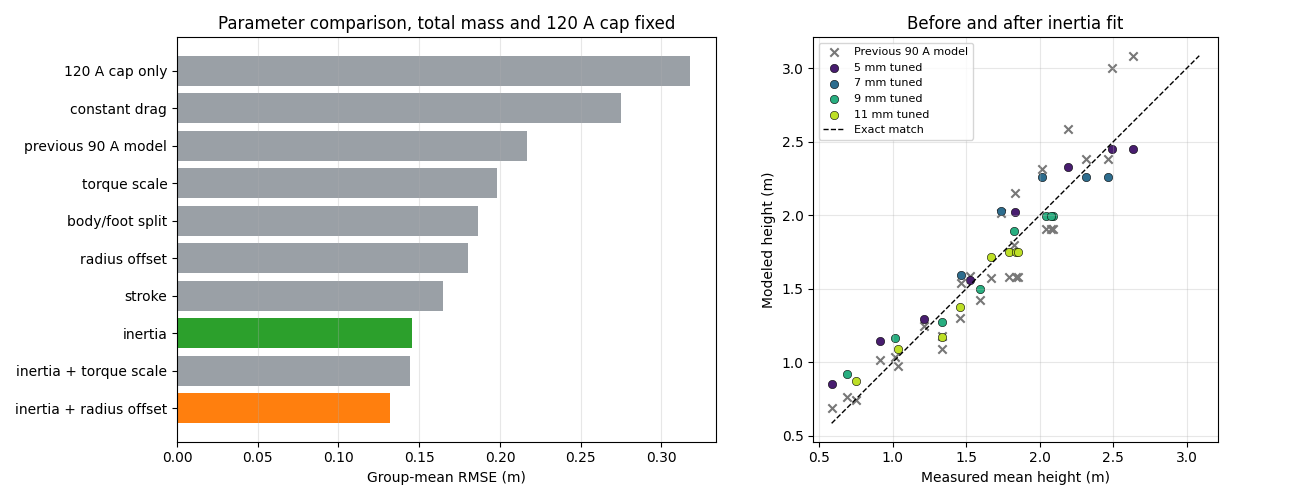

In [5]:
# Parameter fit against measured group means. Total mass and the 120 A torque cap stay fixed.
fit_data = trial_summary.rename(columns={'voltage': 'voltage_v', 'mean': 'height_m'})
fit_data = fit_data[['radius_m', 'voltage_v', 'height_m']].copy()

def simulate_jump_height(voltage, radius_m, inertia, torque_cap_nm, torque_scale=1.0,
                         body_mass=mass, drag_force_n=0.0, radius_offset_m=0.0,
                         stroke_m=stroke, total_mass_kg=mass_total):
    radius = radius_m + radius_offset_m

    def geometry(theta):
        val = max(L**2 - (radius * theta)**2, 1e-12)
        root = np.sqrt(val)
        return (
            L - root,
            radius**2 * theta / root,
            radius**2 * L**2 / val**1.5,
        )

    def dynamics_fit(t, state):
        theta, theta_dot = state
        _, dy_dtheta, d2y_dtheta2 = geometry(theta)
        rpm = theta_dot * 60 / (2 * np.pi)
        free_speed_rpm = np.interp(voltage, VOLTAGE_POINTS, FREE_SPEED_RPM)
        slope = SLOPE_0 + SLOPE_RATE * min(voltage, SLOPE_KNEE_V)
        motor_tau = torque_scale * min(slope * (rpm - free_speed_rpm), torque_cap_nm)
        theta_ddot = (
            -theta_dot**2 * body_mass * dy_dtheta * d2y_dtheta2
            -body_mass * params['g'] * dy_dtheta
            -drag_force_n * dy_dtheta
            +motor_tau
        ) / (inertia + body_mass * dy_dtheta**2)
        return [theta_dot, theta_ddot]

    def stroke_event(t, state):
        return geometry(state[0])[0] - stroke_m

    stroke_event.terminal = True
    stroke_event.direction = 1
    sol = solve_ivp(
        dynamics_fit, (0, 2), [0, 0], events=stroke_event,
        rtol=3e-6, atol=1e-8, max_step=0.005,
    )
    theta, theta_dot = sol.y_events[0][0]
    final_y_d = geometry(theta)[1] * theta_dot
    v_takeoff = final_y_d * body_mass / total_mass_kg
    return v_takeoff**2 / (2 * params['g'])

def predict_fit(data, values):
    return np.array([
        simulate_jump_height(row.voltage_v, row.radius_m, **values)
        for row in data.itertuples(index=False)
    ])

fixed_120a = {
    'inertia': I_BASELINE,
    'torque_cap_nm': 0.260,
    'torque_scale': 1.0,
    'body_mass': mass,
    'drag_force_n': 0.0,
    'radius_offset_m': 0.0,
    'stroke_m': stroke,
    'total_mass_kg': mass_total,
}
fit_specs = {
    'torque scale': (['torque_scale'], [1.0], ([0.5], [1.3])),
    'body/foot split': (['body_mass'], [mass], ([0.060], [0.115])),
    'constant drag': (['drag_force_n'], [0.1], ([0.0], [2.0])),
    'radius offset': (['radius_offset_mm'], [0.0], ([-1.5], [3.0])),
    'stroke': (['stroke_mm'], [1000 * stroke], ([95.0], [115.0])),
    'inertia': (['inertia_1e6'], [16.0], ([1.0], [30.0])),
    'inertia + torque scale': (
        ['inertia_1e6', 'torque_scale'], [16.0, 1.0], ([1.0, 0.5], [30.0, 1.3])
    ),
    'inertia + radius offset': (
        ['inertia_1e6', 'radius_offset_mm'], [16.0, 0.0], ([1.0, -1.5], [30.0, 3.0])
    ),
}

def unpack_fit(names, x):
    values = fixed_120a.copy()
    for name, value in zip(names, x):
        if name == 'inertia_1e6':
            values['inertia'] = value * 1e-6
        elif name == 'radius_offset_mm':
            values['radius_offset_m'] = value / 1000
        elif name == 'stroke_mm':
            values['stroke_m'] = value / 1000
        else:
            values[name] = value
    return values

def score_model(label, values, data=fit_data):
    measured = data['height_m'].to_numpy()
    predicted = predict_fit(data, values)
    return {
        'model': label,
        'rmse_m': np.sqrt(np.mean((predicted - measured)**2)),
        'mae_m': np.mean(np.abs(predicted - measured)),
        'inertia_1e6_kg_m2': 1e6 * values['inertia'],
        'torque_cap_nm': values['torque_cap_nm'],
        'torque_scale': values['torque_scale'],
        'body_mass_kg': values['body_mass'],
        'foot_mass_kg': mass_total - values['body_mass'],
        'drag_force_n': values['drag_force_n'],
        'radius_offset_mm': 1000 * values['radius_offset_m'],
        'stroke_m': values['stroke_m'],
    }

fit_rows = [
    score_model('previous 90 A model', {**fixed_120a, 'torque_cap_nm': TORQUE_CAP_BASELINE_NM}),
    score_model('120 A cap only', fixed_120a),
]
fit_values = {}
for label, (names, x0, bounds) in fit_specs.items():
    measured = fit_data['height_m'].to_numpy()
    result = least_squares(
        lambda x: predict_fit(fit_data, unpack_fit(names, x)) - measured,
        x0, bounds=bounds, max_nfev=100,
        ftol=2e-6, xtol=2e-6, gtol=2e-6,
    )
    values = unpack_fit(names, result.x)
    fit_values[label] = values
    fit_rows.append(score_model(label, values))

fit_results = pd.DataFrame(fit_rows).sort_values('rmse_m').reset_index(drop=True)
adopted_values = fit_values['inertia']
print(f"Optimizer inertia: {adopted_values['inertia']:.8g} kg m²; plotted inertia: {I:.8g} kg m²")

# Leave one radius out: this checks whether the fitted inertia is radius-specific.
cv_rows = []
for held_radius in sorted(fit_data['radius_m'].unique()):
    train = fit_data[~np.isclose(fit_data['radius_m'], held_radius)]
    test = fit_data[np.isclose(fit_data['radius_m'], held_radius)]
    train_y = train['height_m'].to_numpy()
    result = least_squares(
        lambda x: predict_fit(train, unpack_fit(['inertia_1e6'], x)) - train_y,
        [16.0], bounds=([1.0], [30.0]), max_nfev=60,
    )
    values = unpack_fit(['inertia_1e6'], result.x)
    error = predict_fit(test, values) - test['height_m'].to_numpy()
    cv_rows.append({
        'held_radius_mm': 1000 * held_radius,
        'fitted_inertia_1e6_kg_m2': 1e6 * values['inertia'],
        'test_rmse_m': np.sqrt(np.mean(error**2)),
        'test_bias_m': np.mean(error),
    })
cross_validation = pd.DataFrame(cv_rows)

fig_fit, fit_axes = plt.subplots(1, 2, figsize=(13, 5))
plot_fit = fit_results.sort_values('rmse_m', ascending=True)
bar_colors = [
    '#2ca02c' if name == 'inertia' else '#ff7f0e' if name == 'inertia + radius offset' else '#9aa0a6'
    for name in plot_fit['model']
]
fit_axes[0].barh(plot_fit['model'], plot_fit['rmse_m'], color=bar_colors)
fit_axes[0].set_xlabel('Group-mean RMSE (m)')
fit_axes[0].set_title('Parameter comparison, total mass and 120 A cap fixed')
fit_axes[0].grid(axis='x', alpha=0.3)

measured = fit_data['height_m'].to_numpy()
previous = predict_fit(fit_data, {**fixed_120a, 'torque_cap_nm': TORQUE_CAP_BASELINE_NM})
adopted = predict_fit(fit_data, adopted_values)
fit_axes[1].scatter(measured, previous, marker='x', color='#777777', label='Previous 90 A model')
for radius_m in sorted(fit_data['radius_m'].unique()):
    selected = np.isclose(fit_data['radius_m'], radius_m)
    fit_axes[1].scatter(
        measured[selected], adopted[selected], color=radius_colors[radius_m],
        edgecolor='black', linewidth=0.4, label=f'{1000 * radius_m:.0f} mm tuned',
    )
limits = [min(measured.min(), adopted.min()), max(measured.max(), previous.max())]
fit_axes[1].plot(limits, limits, 'k--', linewidth=1, label='Exact match')
fit_axes[1].set(xlabel='Measured mean height (m)', ylabel='Modeled height (m)',
                title='Before and after inertia fit')
fit_axes[1].set_aspect('equal', adjustable='box')
fit_axes[1].grid(alpha=0.3)
fit_axes[1].legend(fontsize=8)
fig_fit.tight_layout()

print(f'Adopted inertia: {I:.6g} kg m²; total mass fixed: {mass_total:.3f} kg; torque cap fixed: {TORQUE_CAP_NM:.3f} Nm')
display(fit_results.round(6))
display(cross_validation.round(6))


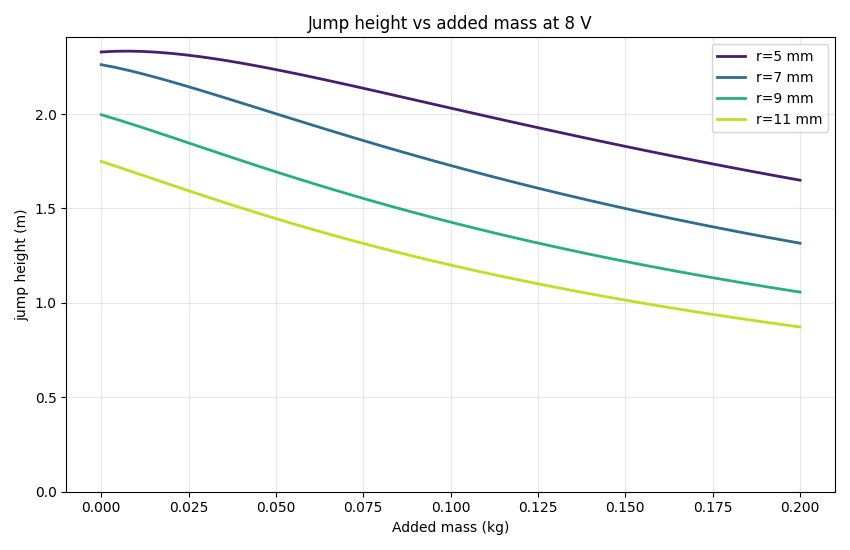

In [6]:
# Added-body-mass sweep. Foot mass remains fixed; total mass increases with payload.
MASS_SWEEP_VOLTAGE = 8
mass_foot = 0.035
added_inertias = np.linspace(0, 10e-5, 51)
added_masses = np.linspace(0, 0.200, 51)
sweep_rows = []

radius_tests = [0.005, 0.007, 0.009, 0.011]
radius_colors = dict(zip(radius_tests, plt.cm.viridis(np.linspace(0.08, 0.9, len(radius_tests)))))

for radius_m in radius_tests:
    # for added_inertia in added_inertias:
    for added_mass in added_masses:
        body_mass_kg = mass + added_mass
        total_mass_kg = body_mass_kg + mass_foot
        height_m = simulate_jump_height(
            voltage=MASS_SWEEP_VOLTAGE,
            radius_m=radius_m,
            inertia=I,
            torque_cap_nm=TORQUE_CAP_NM,
            body_mass=body_mass_kg,
            total_mass_kg=total_mass_kg,
        )
        sweep_rows.append({
            'radius_mm': 1000 * radius_m,
            'sweep_param': added_mass,
            'jump_height_m': height_m,
        })

sweep_results = pd.DataFrame(sweep_rows)
fig_sweep, ax_sweep = plt.subplots(figsize=(8.5, 5.5))
for radius_m in radius_tests:
    radius_data = sweep_results[np.isclose(
        sweep_results['radius_mm'], 1000 * radius_m
    )]
    ax_sweep.plot(
        radius_data['sweep_param'],
        radius_data['jump_height_m'],
        color=radius_colors[radius_m],
        linewidth=2,
        label=f'r={1000 * radius_m:.0f} mm',
    )
ax_sweep.set_xlabel('Added mass (kg)')
ax_sweep.set_ylabel('jump height (m)')
ax_sweep.set_title(
    f'Jump height vs added mass at {MASS_SWEEP_VOLTAGE:.0f} V'
    # f'foot mass fixed at {1000 * mass_foot:.0f} g; body mass {1000 * mass:.0f} g'
)
# ax_mass.set_xlim(0, 50)
ax_sweep.set_ylim(0, )
ax_sweep.grid(alpha=0.3)
ax_sweep.legend()
fig_sweep.tight_layout()


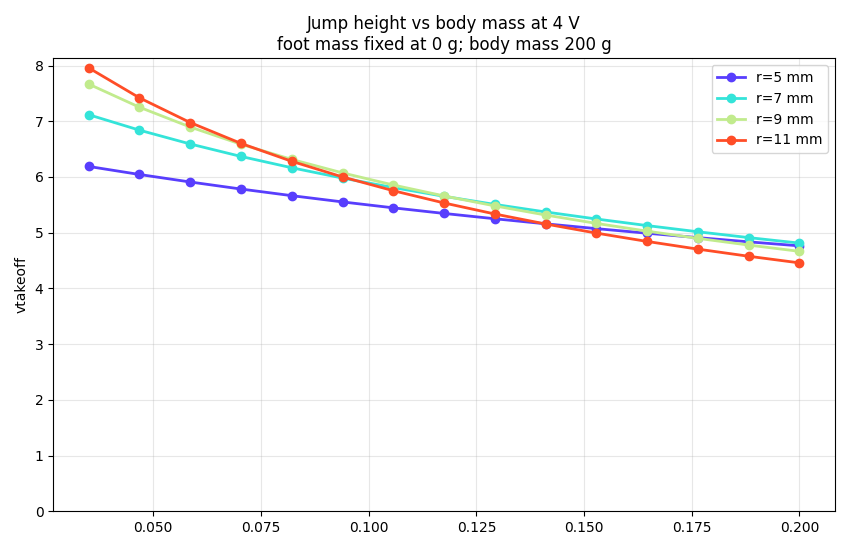

In [7]:
mass_foot = 0.0
I = 5e-5
# I = 1.82396e-05
for MASS_SWEEP_VOLTAGE in [4]:
    added_inertias = np.linspace(0, 10e-5, 51)
    masses = np.linspace(0.035, 0.200, 15)
    sweep_rows = []

    radius_tests = [0.005, 0.007, 0.009, 0.011]
    radius_colors = dict(zip(radius_tests, plt.cm.rainbow(np.linspace(0.08, 0.9, len(radius_tests)))))

    for radius_m in radius_tests:
        for mass in masses:
            body_mass_kg = mass
            total_mass_kg = body_mass_kg + mass_foot
            height_m = simulate_jump_height(
                voltage=MASS_SWEEP_VOLTAGE,
                radius_m=radius_m,
                inertia=I,
                torque_cap_nm=TORQUE_CAP_NM,
                body_mass=body_mass_kg,
                total_mass_kg=total_mass_kg,
            )
            v_takeoff = np.sqrt(height_m * 2*9.81) 
            energy = 0.5 * total_mass_kg * v_takeoff**2
            sweep_rows.append({
                'radius_mm': 1000 * radius_m,
                'sweep_param': body_mass_kg,
                'jump_height_m': height_m,
                'v_takeoff': v_takeoff,
                'energy': energy,
            })

    sweep_results = pd.DataFrame(sweep_rows)
    fig_sweep, ax_sweep = plt.subplots(figsize=(8.5, 5.5))
    for radius_m in radius_tests:
        radius_data = sweep_results[np.isclose(
            sweep_results['radius_mm'], 1000 * radius_m
        )]
        ax_sweep.plot(
            radius_data['sweep_param'],
            # radius_data['energy'],
            radius_data['v_takeoff'],
            'o-',
            color=radius_colors[radius_m],
            linewidth=2,
            label=f'r={1000 * radius_m:.0f} mm',
        )
    # ax_sweep.set_xlabel('body mass (kg)')
    # ax_sweep.set_ylabel('energy J')
    ax_sweep.set_ylabel('vtakeoff')
    ax_sweep.set_title(
        f'Jump height vs body mass at {MASS_SWEEP_VOLTAGE:.0f} V\n'
        f'foot mass fixed at {1000 * mass_foot:.0f} g; body mass {1000 * mass:.0f} g'
    )
    # ax_mass.set_xlim(0, 50)
    ax_sweep.set_ylim(0, )
    ax_sweep.grid(alpha=0.3)
    ax_sweep.legend()
    fig_sweep.tight_layout()

In [8]:
I

5e-05

PosixPath('simple_1d_energy_vs_body_mass_4v.png')

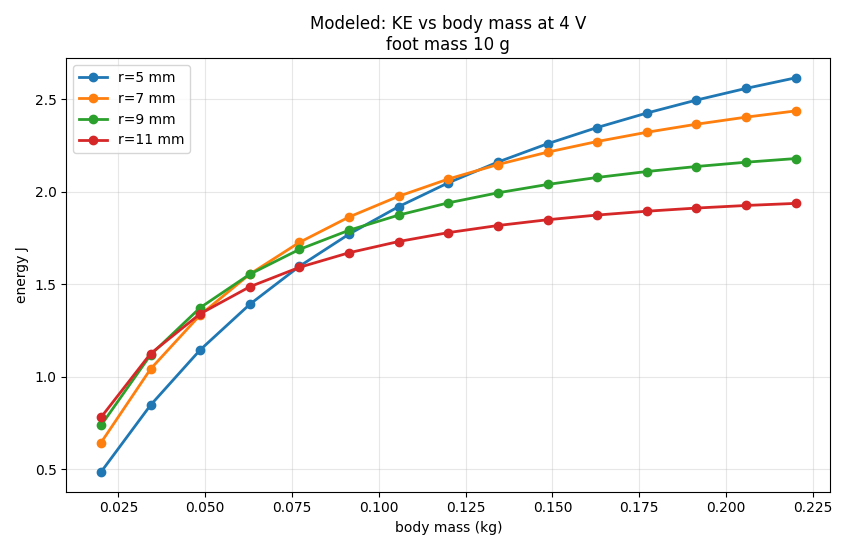

In [22]:
# Original 4 V energy sweep from the earlier notebook version.
# Keep these names separate so this cell does not change other model sweeps.
from pathlib import Path

ORIGINAL_ENERGY_VOLTAGE = 4
ORIGINAL_ENERGY_INERTIA_KG_M2 = 1.82396e-5
ORIGINAL_ENERGY_FOOT_MASS_KG = 0.010
original_energy_masses_kg = np.linspace(0.020, 0.220, 15)
original_energy_radii_m = [0.005, 0.007, 0.009, 0.011]
original_energy_colors = dict(zip(
    original_energy_radii_m,
    plt.cm.rainbow(np.linspace(0.08, 0.9, len(original_energy_radii_m))),
))
original_energy_rows = []

for radius_m in original_energy_radii_m:
    for body_mass_kg in original_energy_masses_kg:
        total_mass_kg = body_mass_kg + ORIGINAL_ENERGY_FOOT_MASS_KG
        jump_height_m = simulate_jump_height(
            voltage=ORIGINAL_ENERGY_VOLTAGE,
            radius_m=radius_m,
            inertia=ORIGINAL_ENERGY_INERTIA_KG_M2,
            torque_cap_nm=TORQUE_CAP_NM,
            body_mass=body_mass_kg,
            total_mass_kg=total_mass_kg,
        )
        takeoff_velocity_m_s = np.sqrt(2 * params['g'] * jump_height_m)
        kinetic_energy_j = 0.5 * total_mass_kg * takeoff_velocity_m_s**2
        original_energy_rows.append({
            'radius_mm': 1000 * radius_m,
            'body_mass_kg': body_mass_kg,
            'jump_height_m': jump_height_m,
            'takeoff_velocity_m_s': takeoff_velocity_m_s,
            'kinetic_energy_j': kinetic_energy_j,
        })

original_energy_results = pd.DataFrame(original_energy_rows)
fig_original_energy, ax_original_energy = plt.subplots(figsize=(8.5, 5.5))
for radius_m in original_energy_radii_m:
    radius_data = original_energy_results[np.isclose(
        original_energy_results['radius_mm'], 1000 * radius_m
    )]
    ax_original_energy.plot(
        radius_data['body_mass_kg'],
        radius_data['kinetic_energy_j'],
        'o-',
        # color=original_energy_colors[radius_m],
        linewidth=2,
        label=f'r={1000 * radius_m:.0f} mm',
    )

ax_original_energy.set_xlabel('body mass (kg)')
ax_original_energy.set_ylabel('energy J')
ax_original_energy.set_title(
    f'Modeled: KE vs body mass at {ORIGINAL_ENERGY_VOLTAGE:.0f} V\n'
    f'foot mass {1000 * ORIGINAL_ENERGY_FOOT_MASS_KG:.0f} g'
    # f'body mass {1000 * original_energy_masses_kg[-1]:.0f} g'
)
ax_original_energy.grid(alpha=0.3)
ax_original_energy.legend()
fig_original_energy.tight_layout()

original_energy_plot_path = Path('simple_1d_energy_vs_body_mass_4v.png')
fig_original_energy.savefig(original_energy_plot_path, dpi=180)
original_energy_plot_path


In [10]:
plt.close('all')